# 03 — Topic Modeling

**Scope change (2026-07-22):** the corpus is now restricted to the Protestant Bible only —
the 66-book Protestant canon, KJV text (see `src/align_corpus.py`). The previous version of
this notebook compared protocanonical vs. deuterocanonical passages within the Catholic
(Douay-Rheims) corpus; that analysis is preserved in git history but cannot be run under
the current scope, since the deuterocanonical books are outside the Protestant canon.

The comparison that remains inside a 66-book canon is **Old Testament vs. New Testament**:
do OT and NT passages occupy measurably different regions of topic space under LDA? The
methodological skeleton is kept from the previous analysis — ~150-word passages, bag-of-words
LDA (scikit-learn, not BERTopic, to avoid the heavy torch install), normalized topic-share
comparison, Jensen-Shannon distance with a permutation test.

**Caveat, stated up front:** OT vs. NT differ in language register, genre mix, and historical
period all at once, so a topic-distribution gap here is descriptive, not evidence of any one
cause. The previous analysis controlled for genre within the OT; that control does not
transfer, because OT and NT genres barely overlap (Law/Prophets vs. Gospels/Epistles).

In [1]:
import json
import sys
from pathlib import Path

sys.path.append('../src')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

from data_loader import load_canon_list

PROCESSED_DIR = Path('../data/processed')

manifest_path = PROCESSED_DIR / 'corpus_manifest.json'
if not manifest_path.exists():
    raise RuntimeError(
        f'{manifest_path} not found. Run `python src/build_processed_corpus.py` first '
        '(see context/NEXT_STEPS.md).'
    )

manifest = json.loads(manifest_path.read_text(encoding='utf-8'))
protestant_books = load_canon_list('protestant')
print(f'{len(protestant_books)} books in the Protestant canon')

66 books in the Protestant canon


## Load the Protestant (KJV) corpus and tag Old vs. New Testament

`load_canon_list('protestant')` returns the 39 OT books followed by the 27 NT books, so the
testament label falls out of list position. Every book's cleaned KJV text comes from
`data/processed/protestant/`.

In [2]:
NT_BOOKS = set(protestant_books[-27:])

book_records = []
for book in protestant_books:
    text_path = PROCESSED_DIR / 'protestant' / f'{book}.txt'
    book_records.append({
        'book': book,
        'category': 'New Testament' if book in NT_BOOKS else 'Old Testament',
        'text': text_path.read_text(encoding='utf-8'),
    })

books_df = pd.DataFrame(book_records)
print(books_df['category'].value_counts())
assert (books_df['category'] == 'New Testament').sum() == 27, 'expected 27 NT books'
assert (books_df['category'] == 'Old Testament').sum() == 39, 'expected 39 OT books'

category
Old Testament    39
New Testament    27
Name: count, dtype: int64


## Chunk into passages

Each book becomes a set of ~150-word passages (last partial passage dropped if under 30
words, to avoid noisy near-empty documents). Every passage inherits its book's testament
label. Same chunking parameters as the previous version of this notebook.

In [3]:
CHUNK_WORDS = 150
MIN_CHUNK_WORDS = 30

passage_records = []
for _, row in books_df.iterrows():
    words = row['text'].split()
    for start in range(0, len(words), CHUNK_WORDS):
        chunk_words = words[start:start + CHUNK_WORDS]
        if len(chunk_words) < MIN_CHUNK_WORDS:
            continue
        passage_records.append({
            'book': row['book'],
            'category': row['category'],
            'text': ' '.join(chunk_words),
        })

passages_df = pd.DataFrame(passage_records)
print(f'{len(passages_df)} passages from {books_df.shape[0]} books')
print(passages_df['category'].value_counts())
print(passages_df.groupby('category')['book'].nunique().rename('unique_books'))

5262 passages from 66 books
category
Old Testament    4059
New Testament    1203
Name: count, dtype: int64
category
New Testament    27
Old Testament    39
Name: unique_books, dtype: int64


## Fit LDA

Bag-of-words with English stopwords removed, common/rare-word filtering (`max_df`/`min_df`),
and a capped vocabulary. `n_components=12` carries over from the previous analysis, where a
K sweep ({4..28}, perplexity + UMass coherence) favored small K on fit metrics alone but
K=12 was kept for interpretability — treat it as a reasonable default here, not a value
tuned for *this* corpus.

In [4]:
N_TOPICS = 12

vectorizer = CountVectorizer(stop_words='english', max_df=0.9, min_df=3, max_features=2000)
doc_term_matrix = vectorizer.fit_transform(passages_df['text'])
feature_names = vectorizer.get_feature_names_out()
print(f'{doc_term_matrix.shape[0]} passages x {doc_term_matrix.shape[1]} vocab terms')

lda = LatentDirichletAllocation(n_components=N_TOPICS, random_state=42, max_iter=20)
doc_topic_matrix = lda.fit_transform(doc_term_matrix)
passages_df['dominant_topic'] = doc_topic_matrix.argmax(axis=1)

5262 passages x 2000 vocab terms


In [5]:
def top_words(topic_weights, n=10):
    return [feature_names[i] for i in topic_weights.argsort()[-n:][::-1]]

for topic_idx, topic_weights in enumerate(lda.components_):
    print(f'Topic {topic_idx:2d}: {", ".join(top_words(topic_weights))}')

Topic  0: children, sons, thousand, son, tribe, cities, unto, families, brethren, inheritance
Topic  1: unto, shall, said, father, man, hath, wife, son, say, woman
Topic  2: david, men, said, went, saul, came, unto, israel, people, philistines
Topic  3: lord, unto, ye, shall, land, god, israel, people, saith, said
Topic  4: king, son, said, israel, house, unto, came, lord, david, judah
Topic  5: god, ye, unto, things, christ, man, hath, lord, jesus, let
Topic  6: unto, said, came, jesus, went, man, saying, come, saw, ye
Topic  7: lord, unto, king, israel, moses, people, children, house, aaron, god
Topic  8: shall, offering, unto, lord, priest, altar, burnt, offerings, holy, offer
Topic  9: shall, lord, hath, man, earth, come, like, away, men, day
Topic 10: thou, thy, thee, lord, shalt, hast, unto, god, thine, shall
Topic 11: gold, thereof, house, silver, cubits, gate, trees, solomon, round, brass


## Compare topic distributions: Old Testament vs. New Testament

Normalized within each category (columns sum to 1), so this compares *proportions* rather
than raw counts — necessary since OT passages outnumber NT passages roughly 3.5 to 1.

In [6]:
topic_by_category = pd.crosstab(
    passages_df['dominant_topic'], passages_df['category'], normalize='columns'
)
topic_by_category

category,New Testament,Old Testament
dominant_topic,,
0,0.000831,0.040158
1,0.078138,0.025622
2,0.001663,0.065041
3,0.012469,0.160877
4,0.004988,0.094358
5,0.391521,0.008376
6,0.419784,0.051491
7,0.000000,0.102735
8,0.001663,0.055925


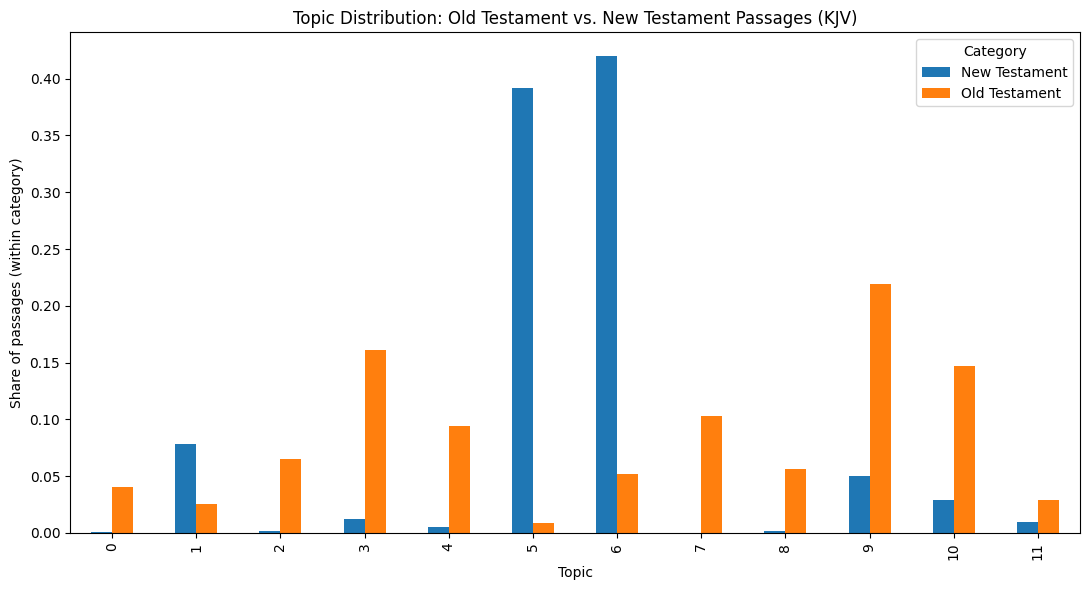

In [7]:
fig, ax = plt.subplots(figsize=(11, 6))
topic_by_category.plot(kind='bar', ax=ax)
ax.set_xlabel('Topic')
ax.set_ylabel('Share of passages (within category)')
ax.set_title('Topic Distribution: Old Testament vs. New Testament Passages (KJV)')
ax.legend(title='Category')
plt.tight_layout()
plt.savefig('../outputs/figures/topic_distribution_ot_vs_nt.png', dpi=150)
plt.show()

## How large is the gap? Jensen-Shannon distance + permutation test

Jensen-Shannon distance between the two normalized topic distributions (symmetric, bounded
[0, 1], 0 = identical). The permutation test reshuffles the OT/NT labels across passages
3,000 times and asks how often a gap this large arises by chance — valid at any sample
size, matching the approach the previous analysis settled on after finding chi-square
unreliable for small cells.

In [8]:
from scipy.spatial.distance import jensenshannon

def topic_share(dominant_topics, n_topics):
    counts = np.bincount(dominant_topics, minlength=n_topics).astype(float)
    return counts / counts.sum()

ot_topics = passages_df.loc[passages_df.category == 'Old Testament', 'dominant_topic'].to_numpy()
nt_topics = passages_df.loc[passages_df.category == 'New Testament', 'dominant_topic'].to_numpy()

observed_jsd = jensenshannon(topic_share(ot_topics, N_TOPICS), topic_share(nt_topics, N_TOPICS), base=2)

rng = np.random.default_rng(0)
all_topics = passages_df['dominant_topic'].to_numpy()
n_ot = len(ot_topics)
n_perm = 3000
perm_jsds = np.empty(n_perm)
for i in range(n_perm):
    shuffled = rng.permutation(all_topics)
    perm_jsds[i] = jensenshannon(
        topic_share(shuffled[:n_ot], N_TOPICS),
        topic_share(shuffled[n_ot:], N_TOPICS),
        base=2,
    )

permutation_p = (1 + np.sum(perm_jsds >= observed_jsd)) / (1 + n_perm)
print(f'Observed OT/NT JSD: {observed_jsd:.3f}')
print(f'Permutation null:   mean {perm_jsds.mean():.3f}, max {perm_jsds.max():.3f} over {n_perm} shuffles')
print(f'Permutation p:      {permutation_p:.4f}')

Observed OT/NT JSD: 0.765
Permutation null:   mean 0.045, max 0.084 over 3000 shuffles
Permutation p:      0.0003


## Per-book sanity check

Dominant topic mix for a few structurally different books — a wisdom book (Psalms), an OT
narrative (2 Kings, kept from the previous notebook's Elisha's-bones case study), a Gospel
(John), and an epistle (Romans). If the model is picking up real structure, these should
lean on visibly different topics.

In [9]:
for book in ('Psalms', '2 Kings', 'John', 'Romans'):
    counts = passages_df.loc[passages_df['book'] == book, 'dominant_topic'].value_counts()
    print(f'{book}:')
    print(counts.head(4).to_string(), '\n')

Psalms:
dominant_topic
10    157
9      95
3      28
5       4 

2 Kings:
dominant_topic
4    49
6    16
2    10
7     4 

John:
dominant_topic
6     71
5     26
1     24
10     5 

Romans:
dominant_topic
5     57
10     3
3      2
1      1 



**Read this alongside the printed topic word lists above** — look at which topics dominate
each testament and whether the words fit expected register differences (e.g. a
kings-and-battles narrative topic vs. a grace/faith epistolary topic). This notebook doesn't
hardcode an interpretation, since the topic words shift with `N_TOPICS` and `random_state`.

## Next steps

- Re-tune `N_TOPICS` for this corpus specifically (the K sweep in the previous version was
  run on the Catholic corpus; its conclusion doesn't automatically carry over).
- Seed-stability check for the OT/NT JSD, mirroring the previous version's seed sweep.
- Decide what research question this comparison serves in the thesis now that the
  proto/deuterocanonical comparison is out of scope — see `docs/thesis.md`, whose Results
  sections still describe the old analysis.